# Imports

In [1]:
import requests
import json 
import pandas as pd
import string
from collections import Counter
from htrc_features import Volume
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Import Worksets

In [62]:
workset = requests.get("https://worksets.hathitrust.org/wsid/69ffac70-24da-11f1-806f-2d821d8659ab")

workset_content = workset.content
data = json.loads(workset_content)


data = data['gathers']

readable_json = json.dumps(data, indent=4) # Indent with 4 spaces
print(readable_json)

[
    {
        "id": "http://hdl.handle.net/2027/mdp.39015011239624"
    },
    {
        "id": "http://hdl.handle.net/2027/mdp.39015010753476"
    }
]


In [63]:
x = readable_json.split()
y = "http://hdl.handle.net/2027/"
volumes_en = []
for i in x:
    if y in i:
        z = i.replace(y,"")
        z = z.replace('"',"")
        volumes_en.append(z)

print (volumes_en)

['mdp.39015011239624', 'mdp.39015010753476']


# Import Stopwords

In [3]:
stop_en = requests.get('https://data.analytics.hathitrust.org/data/text/default_stopwords_en.txt')
stop_en = stop_en.text
stop_en = stop_en.split()
stop_en

['a',
 "a's",
 'able',
 'about',
 'above',
 'according',
 'accordingly',
 'across',
 'actually',
 'after',
 'afterwards',
 'again',
 'against',
 "ain't",
 'all',
 'allow',
 'allows',
 'almost',
 'alone',
 'along',
 'already',
 'also',
 'although',
 'always',
 'am',
 'among',
 'amongst',
 'an',
 'and',
 'another',
 'any',
 'anybody',
 'anyhow',
 'anyone',
 'anything',
 'anyway',
 'anyways',
 'anywhere',
 'apart',
 'appear',
 'appreciate',
 'appropriate',
 'are',
 "aren't",
 'around',
 'as',
 'aside',
 'ask',
 'asking',
 'associated',
 'at',
 'available',
 'away',
 'awfully',
 'b',
 'be',
 'became',
 'because',
 'become',
 'becomes',
 'becoming',
 'been',
 'before',
 'beforehand',
 'behind',
 'being',
 'believe',
 'below',
 'beside',
 'besides',
 'best',
 'better',
 'between',
 'beyond',
 'both',
 'brief',
 'but',
 'by',
 'c',
 "c'mon",
 "c's",
 'came',
 'can',
 "can't",
 'cannot',
 'cant',
 'cause',
 'causes',
 'certain',
 'certainly',
 'changes',
 'clearly',
 'co',
 'com',
 'come',
 'c

In [4]:
stop_rus = requests.get('https://raw.githubusercontent.com/hingston/russian/refs/heads/master/10000-russian-words-cyrillic-only.txt')
stop_rus = stop_rus.text
stop_rus = stop_rus.split()
stop_rus

['и',
 'в',
 'не',
 'на',
 'я',
 'что',
 'быть',
 'с',
 'он',
 'а',
 'это',
 'как',
 'то',
 'этот',
 'по',
 'к',
 'но',
 'они',
 'мы',
 'она',
 'который',
 'из',
 'у',
 'свой',
 'вы',
 'весь',
 'за',
 'для',
 'от',
 'о',
 'так',
 'мочь',
 'все',
 'ты',
 'же',
 'год',
 'человек',
 'один',
 'такой',
 'тот',
 'или',
 'если',
 'только',
 'его',
 'бы',
 'себя',
 'время',
 'когда',
 'еще',
 'уже',
 'другой',
 'сказать',
 'до',
 'мой',
 'наш',
 'чтобы',
 'говорить',
 'самый',
 'знать',
 'вот',
 'очень',
 'нет',
 'кто',
 'при',
 'да',
 'стать',
 'день',
 'первый',
 'даже',
 'можно',
 'жизнь',
 'во',
 'ни',
 'сам',
 'дело',
 'два',
 'новый',
 'раз',
 'хотеть',
 'должен',
 'ли',
 'какой',
 'со',
 'там',
 'их',
 'много',
 'работа',
 'иметь',
 'после',
 'где',
 'вопрос',
 'рука',
 'город',
 'ее',
 'под',
 'каждый',
 'слово',
 'место',
 'без',
 'ну',
 'ребенок',
 'просто',
 'более',
 'друг',
 'большой',
 'надо',
 'чем',
 'ваш',
 'сделать',
 'идти',
 'здесь',
 'делать',
 'сейчас',
 'россия',
 'видет

# Upload/Clean Volumes

In [5]:
vol_en = Volume('mdp.39015010753476', download=True)

counter_en = Counter()

for page in vol_en.pages():
    for word in page.tokens():
            counter_en.update(page.tokens())  

In [6]:
df_english = pd.DataFrame({'count': counter_en})
df_english = df_english.reset_index()
df_english = df_english.rename(columns={'index': 'word'})
df_english = df_english.sort_values(by='count', ascending=False)
df_english = df_english[~df_english['word'].isin(stop_en)]
df_english = df_english[~df_english['word'].isin(stop.title() for stop in stop_en)]
df_english = df_english[~df_english['word'].isin(list(string.punctuation))]
df_english = df_english[~df_english['word'].isin(["'s","''","-RRB-","-LRB-","``","--","p."])]

In [7]:
df_english.head(50)

,word,count
209,nuclear,71961
365,U.S.,46441
48,weapons,45959
969,uranium,42251
983,plant,40633
26,United,39144
2,Nuclear,39071
42,States,38198
949,fuel,37831
970,reactor,37415


In [8]:
vol_rus = Volume('mdp.39015011239624', download=True)

counter_rus = Counter()

for page in vol_rus.pages():
    for word in page.tokens():
            counter_rus.update(page.tokens())  

In [9]:
df_russian = pd.DataFrame({'count': counter_rus})
df_russian = df_russian.reset_index()
df_russian = df_russian.rename(columns={'index': 'word'})
df_russian = df_russian.sort_values(by='count', ascending=False)
df_russian = df_russian[~df_russian['word'].isin(stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(stop.title() for stop in stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(list(string.punctuation))]
df_russian = df_russian[~df_russian['word'].isin(["«","»", "—","»,","».", '".', '»".'])]

In [10]:
df_russian.head(50)

,word,count
180,США,48027
86,стран,37060
75,Западной,29156
237,страны,24291
377,Европы,23072
1288,года,20306
1386,американской,19665
447,западноевропейских,19558
249,политики,18569
560,Европе,17405


# Word Clouds

In [11]:
eng = ' '.join(df_english['word'].astype(str).tolist())

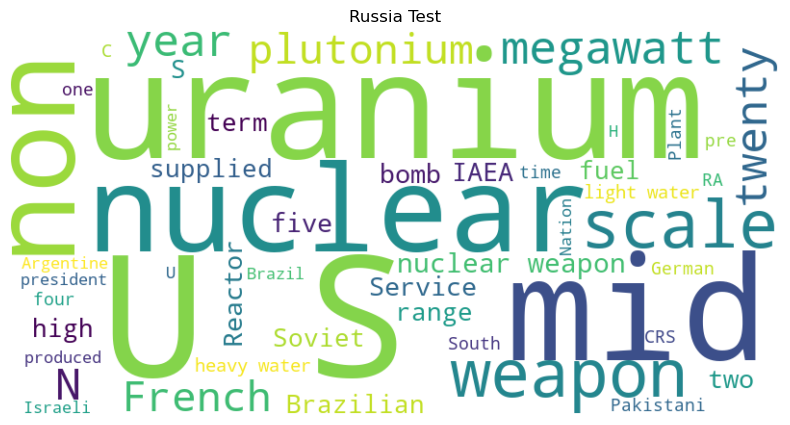

In [12]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(eng)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

In [13]:
rus = ' '.join(df_russian['word'].astype(str).tolist())

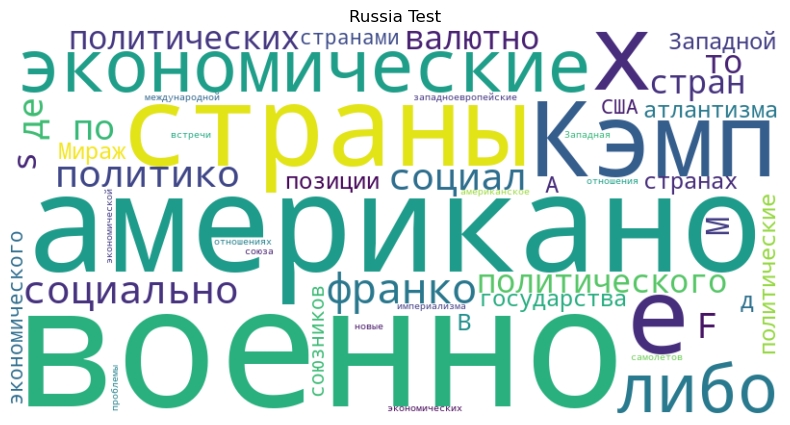

In [14]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(rus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

# Multivolumes

In [64]:
counter_test = Counter()
for i in volumes_en:
    vol_test = Volume(i, download=True)
    for page in vol_test.pages():
        for word in page.tokens():
            counter_test.update(page.tokens())  

In [16]:
test = pd.DataFrame({'count': counter_test})
test = test.reset_index()
test = test.rename(columns={'index': 'word'})
test = test.sort_values(by='count', ascending=False)
test = test[~test['word'].isin(stop_en)]
test = test[~test['word'].isin(stop.title() for stop in stop_en)]
test = test[~test['word'].isin(list(string.punctuation))]
test = test[~test['word'].isin(["'s","''","-RRB-","-LRB-","``","--","p."])]
test.head()

,word,count
209,nuclear,84565
365,U.S.,62606
26,United,59171
42,States,58344
48,weapons,53556
